# Acidification Profiles in Cheese Making

**Contact:** Dimitri Bocquel  
**Authors:** Lilandra Albert-Lavault & Samuele Moungang  
**Data collected:** 05 mai 2026

| Source | File | Résolution | Canaux |
|--------|------|------------|--------|
| Fromage 1 — USB | `00000005.CSV` | 1 min | pH, mV |
| Fromage 2 — Server | `trace_pH_fromage_2_Server_05052026.csv` | ~1 s | pH |
| Fromage 3 — Hannah (PHLOT002) | `trace_pH_fromage_3_05052026_hannah.CSV` | 1 min | pH, mV, T°C |

---

## Pipeline
1. **Load & inspect** raw data
2. **Interpolation** — combler les lacunes du signal server (grille 1 s régulière)
3. **Resampling** — grille 1 min commune
4. **Correction Nernst** — corriger le pH mesuré en fonction de la température réelle de l'électrode
5. **Fit logistique** — ajustement d'un modèle de déclin logistique
6. **Modèle Luedeking-Piret** — décomposition de la cinétique d'acidification

---
## 0. Setup

In [1]:
import sys
import os
# Décommentez si scipy est absent :
# !{sys.executable} -m pip install scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

plt.rcParams.update({
    'figure.figsize': (14, 4.5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

FIGURES_DIR = 'figures_05052026'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Constantes physiques — équation de Nernst
R    = 8.314      # J mol⁻¹ K⁻¹
F    = 96485.0    # C mol⁻¹
LN10 = np.log(10)

def nernst_slope(T_celsius):
    """Pente de Nernst théorique en mV/pH à la température T (°C)."""
    return -(R * (T_celsius + 273.15) * LN10 / F) * 1000

T_CAL = 25.0   # Température de calibration de référence supposée (USB & Server)
print(f'Pente Nernst @ {T_CAL}°C : {nernst_slope(T_CAL):.3f} mV/pH')
print(f'Pente Nernst @ 37°C    : {nernst_slope(37):.3f} mV/pH')

Pente Nernst @ 25.0°C : -59.156 mV/pH
Pente Nernst @ 37°C    : -61.537 mV/pH


---
## 1. Chargement & Inspection des Données Brutes

In [4]:
# ── Fromage 1 — USB (pH + mV, 1 min) — 05/05/2026 ──────────────────────────
df1_raw = pd.read_csv(
    'data_5_mai/00000005.CSV',
    usecols=['Date', 'Time', 'Ch1_M1', 'Ch1_M3'],
)
df1_raw['datetime'] = pd.to_datetime(
    df1_raw['Date'] + ' ' + df1_raw['Time'], format='%d/%b/%Y %H:%M:%S'
)
df1_raw['pH'] = pd.to_numeric(df1_raw['Ch1_M1'], errors='coerce')
df1_raw['mV'] = pd.to_numeric(df1_raw['Ch1_M3'], errors='coerce')
df1_all = df1_raw[['datetime', 'pH', 'mV']].dropna().set_index('datetime').sort_index()

# Filtre 1 : journée du 05 mai uniquement (la clé enregistre en continu sur plusieurs jours)
df1_all = df1_all[df1_all.index.date == pd.Timestamp('2026-05-05').date()]

# Filtre 2 : supprimer les artefacts (sonde hors du lait, calibrations)
# pH < 3.5 ou > 7.0 = sonde à l'air ou en solution de rinçage
df1_all = df1_all[(df1_all['pH'] >= 3.5) & (df1_all['pH'] <= 7.0)].copy()

# Filtre 3 : fenêtre fermentation active — la sonde quitte le lait vers 15:20
# (valeurs qui chutent à ~3.95 = sonde dans solution acide / à l'air)
df1 = df1_all[
    (df1_all.index >= pd.Timestamp('2026-05-05 10:00:00')) &
    (df1_all.index <= pd.Timestamp('2026-05-05 15:20:00'))
].copy()

print(f'Fromage 1 (USB)    : {len(df1):,} points | {df1.index[0]} → {df1.index[-1]}')
print(f'  Artefacts éliminés : {len(df1_raw) - len(df1_all):,} points (pH < 3.5 ou > 7.0)')
print(f'  pH initial : {df1["pH"].iloc[0]:.2f} | pH final : {df1["pH"].iloc[-1]:.2f}')
df1.describe()

Fromage 1 (USB)    : 312 points | 2026-05-05 10:08:52 → 2026-05-05 15:19:52
  Artefacts éliminés : 953 points (pH < 3.5 ou > 7.0)
  pH initial : 5.30 | pH final : 5.22


,pH,mV
count,312.000000,312.000000
mean,5.602276,82.945513
std,0.333557,19.575238
min,5.220000,10.000000
25%,5.330000,67.000000
50%,5.480000,90.000000
75%,5.870000,99.000000
max,6.840000,105.000000


In [5]:
# ── Fromage 2 — Server (pH uniquement, ~1 s) — 05/05/2026 ───────────────────
df2_raw = pd.read_csv(
    'data_5_mai/trace_pH_fromage_2_Server_05052026.csv',
    names=['datetime', 'pH'], skiprows=1,
)
df2_raw['datetime'] = pd.to_datetime(df2_raw['datetime'])
df2_raw['pH'] = pd.to_numeric(df2_raw['pH'], errors='coerce')
df2_raw = df2_raw.dropna().set_index('datetime').sort_index()

# Supprimer les artefacts
df2_clean = df2_raw[(df2_raw['pH'] >= 3.5) & (df2_raw['pH'] <= 7.0)].copy()

# Supprimer la période avant 11:00 (sonde hors mesure réelle)
df2_clean = df2_clean[df2_clean.index >= pd.Timestamp('2026-05-05 11:00:00')]

# Rééchantillonnage à 1 min (médiane)
df2 = df2_clean['pH'].resample('1min').median().dropna().to_frame()

print(f'Fromage 2 (Server) : {len(df2_raw):,} pts bruts | artefacts éliminés : {len(df2_raw) - len(df2_clean):,}')
print(f'  Après filtre + rééchantillonnage 1 min : {len(df2):,} points | {df2.index[0]} → {df2.index[-1]}')
df2.describe()

Fromage 2 (Server) : 1,721 pts bruts | artefacts éliminés : 825
  Après filtre + rééchantillonnage 1 min : 247 points | 2026-05-05 11:00:00 → 2026-05-05 15:18:00


,pH
count,247.000000
mean,5.216856
std,0.382020
min,4.506494
25%,4.887268
50%,5.174614
75%,5.508446
max,6.239230


In [6]:
# ── Fromage 3 — Hannah PHLOT002 (pH + mV + T°C, 1 min) — 05/05/2026 ─────────
# Le fichier utilise ';' comme séparateur et ',' comme décimale (format européen)
df3_raw = pd.read_csv(
    'data_5_mai/trace_pH_fromage_3_05052026_hannah.CSV',
    skiprows=20, header=None, sep=';',
    names=['_', 'rec', 'date', 'time', 'pH', 'u1', 'mV', 'u2', 'temp_C', 'u3', '_2'],
    usecols=['date', 'time', 'pH', 'mV', 'temp_C'],
    encoding='latin-1',
)
df3_raw['datetime'] = pd.to_datetime(
    df3_raw['date'].str.strip() + ' ' + df3_raw['time'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)
for col in ['pH', 'mV', 'temp_C']:
    df3_raw[col] = pd.to_numeric(
        df3_raw[col].astype(str).str.replace(',', '.', regex=False), errors='coerce'
    )
df3_all = df3_raw[['datetime', 'pH', 'mV', 'temp_C']].dropna().set_index('datetime').sort_index()
df3 = df3_all[(df3_all['pH'] >= 3.5) & (df3_all['pH'] <= 7.0)].copy()

print(f'Fromage 3 (Hannah PHLOT002) : {len(df3):,} points | {df3.index[0]} → {df3.index[-1]}')
print(f'  pH final (dernière valeur) : {df3["pH"].iloc[-1]:.2f}  '
      '⚠️ Fermentation probablement incomplète (pH > 5.15 attendu)')
df3.describe()

Fromage 3 (Hannah PHLOT002) : 286 points | 2026-05-05 11:23:27 → 2026-05-05 16:08:28
  pH final (dernière valeur) : 5.15  ⚠️ Fermentation probablement incomplète (pH > 5.15 attendu)


,pH,mV,temp_C
count,286.000000,286.000000,286.000000
mean,5.620000,86.717832,34.725874
std,0.362212,21.296485,2.266684
min,5.150000,39.300000,25.700000
25%,5.270000,66.775000,34.000000
50%,5.485000,94.750000,34.300000
75%,5.960000,107.075000,35.300000
max,6.420000,114.400000,40.100000


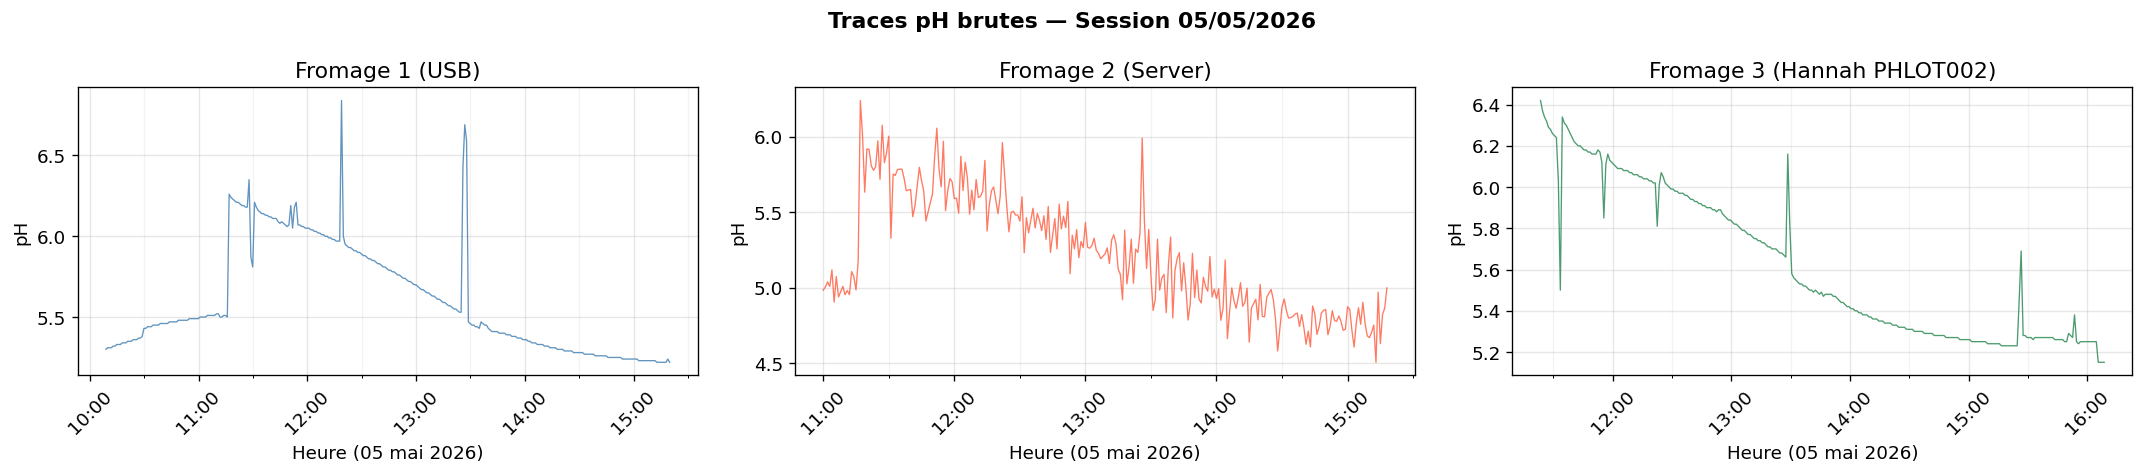

In [7]:
# Vue d'ensemble brute — 3 panneaux
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, df, label, color in zip(
    axes,
    [df1, df2, df3],
    ['Fromage 1 (USB)', 'Fromage 2 (Server)', 'Fromage 3 (Hannah PHLOT002)'],
    ['steelblue', 'tomato', 'seagreen'],
):
    duration_h = (df.index[-1] - df.index[0]).total_seconds() / 3600
    major_interval = 2 if duration_h > 8 else 1

    ax.plot(df.index, df['pH'], color=color, linewidth=0.8, alpha=0.85)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=major_interval))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (05 mai 2026)')

plt.suptitle('Traces pH brutes — Session 05/05/2026', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_raw_traces.png', bbox_inches='tight')
plt.show()

---
## 2. Interpolation — Combler les Lacunes du Signal Server (Fromage 2)

Le logger Server enregistre à ~1 s mais présente des lacunes. On interpole linéairement sur une grille 1 min régulière, en signalant les segments non fiables.

In [8]:
# ── Détection des lacunes ─────────────────────────────────────────────────────
GAP_THRESHOLD_S = 120   # > 2 min = lacune réelle sur grille 1 min
dt_seconds = df2.index.to_series().diff().dt.total_seconds()
gaps = dt_seconds[dt_seconds > GAP_THRESHOLD_S].dropna()
print(f'Lacunes > {GAP_THRESHOLD_S} s dans Fromage 2 : {len(gaps)}')
if len(gaps):
    print(gaps.apply(lambda s: f'{s:.0f} s').to_frame('durée_lacune'))

# ── Grille régulière 1 min ────────────────────────────────────────────────────
t_start     = df2.index[0]
t_end       = df2.index[-1]
regular_idx = pd.date_range(t_start, t_end, freq='1min')

t_orig = (df2.index - t_start).total_seconds().values
t_new  = (regular_idx - t_start).total_seconds().values

interp_fn = interp1d(t_orig, df2['pH'].values, kind='linear',
                     bounds_error=False, fill_value=np.nan)
pH_interp = interp_fn(t_new)

# ── Masquer les segments interpolés dans les grandes lacunes ──────────────────
reliable = np.ones(len(regular_idx), dtype=bool)
for gap_ts, gap_dur in gaps.items():
    prev_ts = gap_ts - pd.Timedelta(seconds=gap_dur)
    mask = (regular_idx > prev_ts) & (regular_idx < gap_ts)
    reliable[mask] = False

df2_interp = pd.DataFrame({'pH': pH_interp, 'reliable': reliable}, index=regular_idx)
print(f'\nGrille régulière : {len(df2_interp):,} pts | fiables : {reliable.sum():,}')

Lacunes > 120 s dans Fromage 2 : 1
                    durée_lacune
datetime                        
2026-05-05 11:50:00        180 s

Grille régulière : 259 pts | fiables : 257


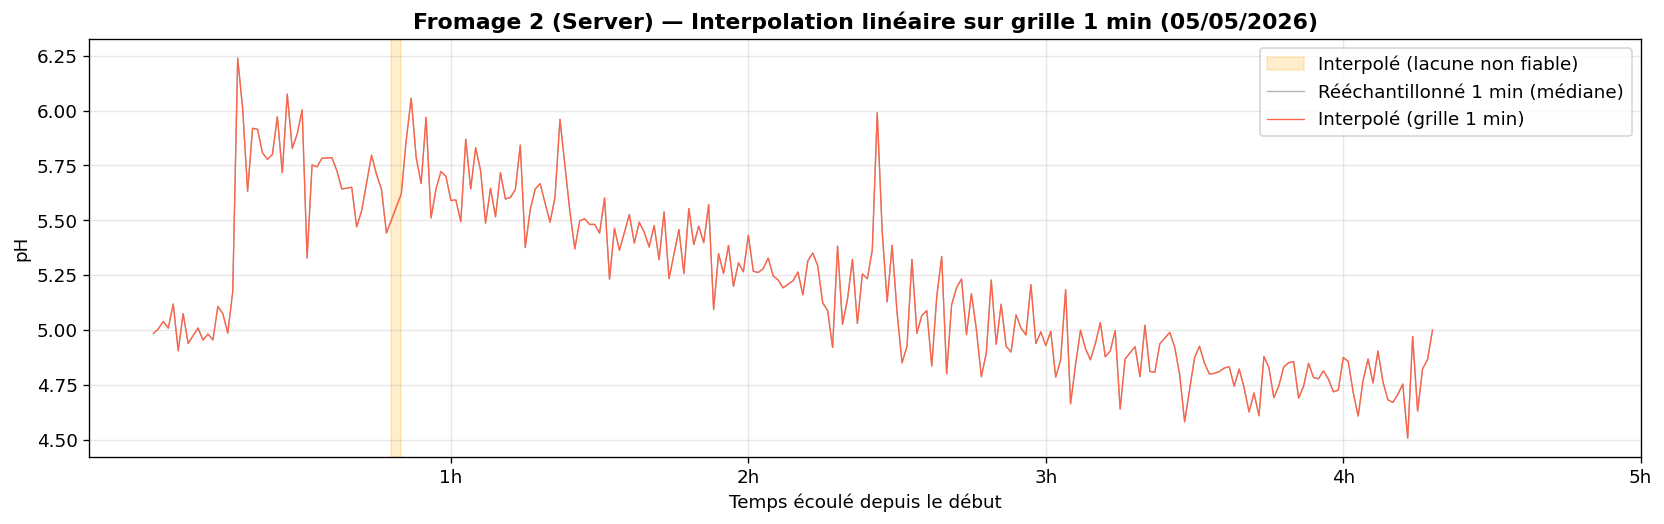

In [9]:
fig, ax = plt.subplots(figsize=(14, 4.5))

t0 = df2_interp.index[0]

def to_hours(idx):
    return (idx - t0).total_seconds() / 3600

# Zones d'interpolation non fiables
in_gap, gap_start = False, None
for ts, row in df2_interp.iterrows():
    if not row['reliable'] and not in_gap:
        gap_start, in_gap = ts, True
    elif row['reliable'] and in_gap:
        ax.axvspan(to_hours(gap_start), to_hours(ts), alpha=0.2, color='orange',
                   label='Interpolé (lacune non fiable)')
        in_gap = False
if in_gap:
    ax.axvspan(to_hours(gap_start), to_hours(df2_interp.index[-1]), alpha=0.2, color='orange')

ax.plot(to_hours(df2.index), df2['pH'],
        color='grey', linewidth=0.8, alpha=0.6, label='Rééchantillonné 1 min (médiane)')
ax.plot(to_hours(df2_interp.index), df2_interp['pH'],
        color='tomato', linewidth=0.8, label='Interpolé (grille 1 min)')

x_max = to_hours(df2_interp.index[-1])
ticks = np.arange(1, int(np.ceil(x_max)) + 1)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{int(t)}h' for t in ticks])

ax.set_title('Fromage 2 (Server) — Interpolation linéaire sur grille 1 min (05/05/2026)', fontweight='bold')
ax.set_xlabel('Temps écoulé depuis le début')
ax.set_ylabel('pH')
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_interpolation.png', bbox_inches='tight')
plt.show()

---
## 3. Rééchantillonnage

Les trois signaux sont rééchantillonnés à la **médiane sur 1 minute** pour obtenir une grille commune.

In [10]:
RESAMPLE_FREQ = '1min'

def resample_data(series, freq=RESAMPLE_FREQ):
    return series.resample(freq).median().dropna()

df1_res = df1_smooth = resample_data(df1['pH'])
df2_res = df2_smooth = resample_data(df2_interp['pH'])
df3_res = df3_smooth = resample_data(df3['pH'])

df1_mV_res   = df1['mV'].resample(RESAMPLE_FREQ).median().dropna()
df3_mV_res   = df3['mV'].resample(RESAMPLE_FREQ).median().dropna()
df3_temp_res = df3['temp_C'].resample(RESAMPLE_FREQ).median().dropna()

print('Tailles après rééchantillonnage :')
for name, s in [('Fromage 1 (USB)', df1_res), ('Fromage 2 (Server)', df2_res), ('Fromage 3 (Hannah)', df3_res)]:
    print(f'  {name} : {len(s):,} points | {s.index[0]} → {s.index[-1]}')

Tailles après rééchantillonnage :
  Fromage 1 (USB) : 312 points | 2026-05-05 10:08:00 → 2026-05-05 15:19:00
  Fromage 2 (Server) : 259 points | 2026-05-05 11:00:00 → 2026-05-05 15:18:00
  Fromage 3 (Hannah) : 286 points | 2026-05-05 11:23:00 → 2026-05-05 16:08:00


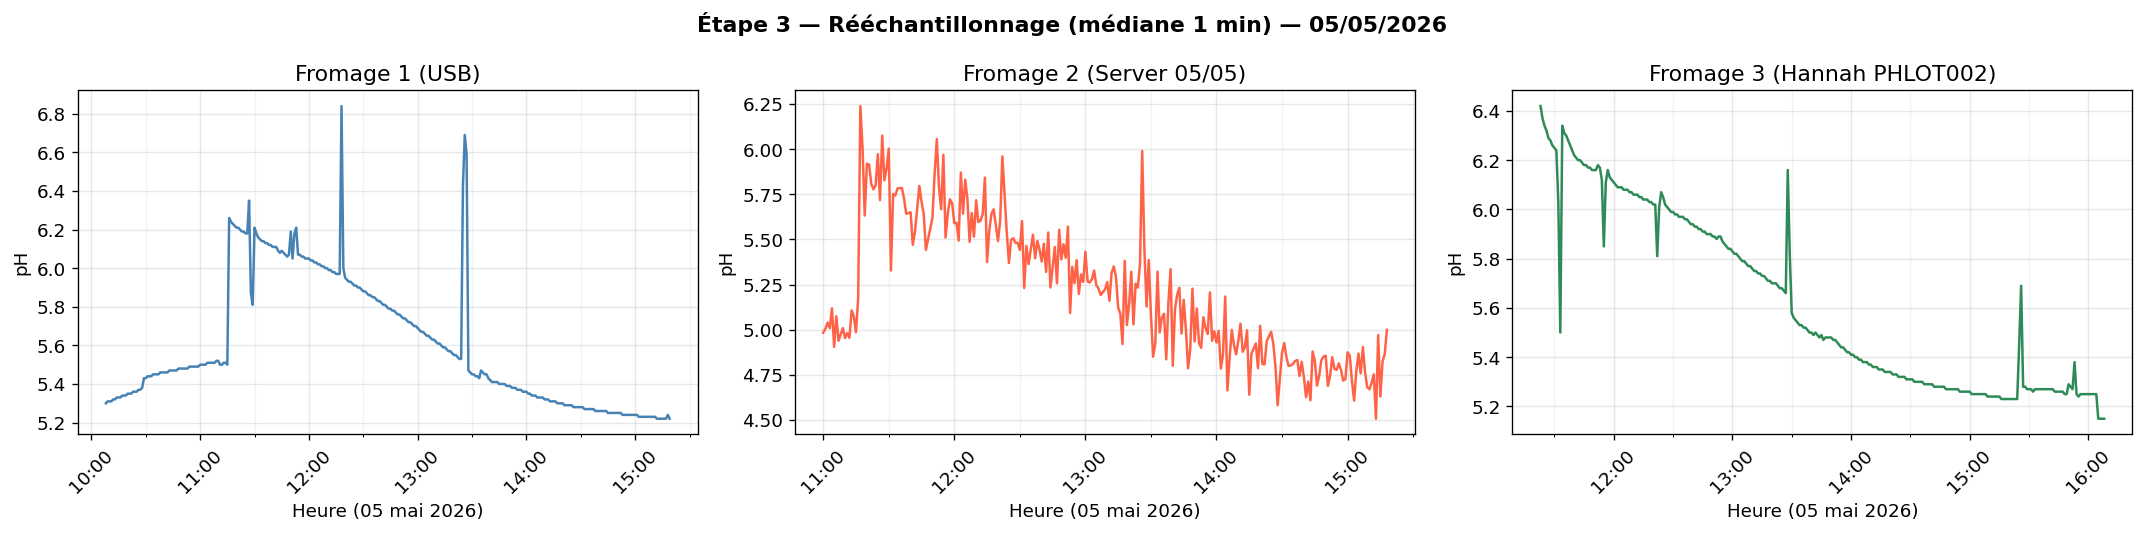

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

datasets = [
    (df1_res, 'Fromage 1 (USB)',              'steelblue'),
    (df2_res, 'Fromage 2 (Server 05/05)',      'tomato'),
    (df3_res, 'Fromage 3 (Hannah PHLOT002)',   'seagreen'),
]

for ax, (res, label, color) in zip(axes, datasets):
    ax.plot(res.index, res.values, color=color, linewidth=1.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (05 mai 2026)')

plt.suptitle('Étape 3 — Rééchantillonnage (médiane 1 min) — 05/05/2026', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_resampling.png', bbox_inches='tight')
plt.show()

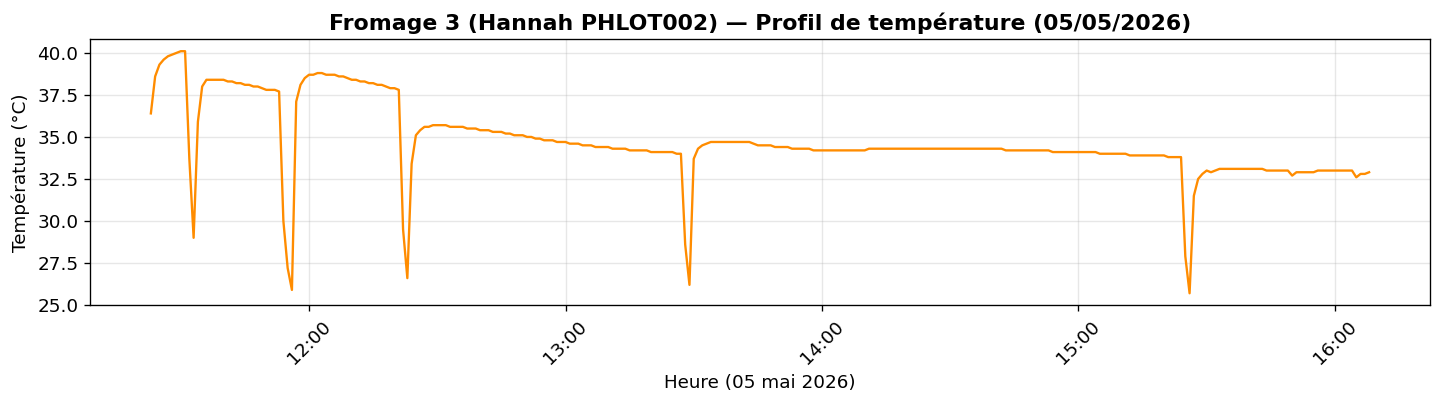

In [12]:
# Profil de température — Fromage 3 (Hannah PHLOT002)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df3_temp_res.index, df3_temp_res.values, color='darkorange', linewidth=1.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_title('Fromage 3 (Hannah PHLOT002) — Profil de température (05/05/2026)', fontweight='bold')
ax.set_ylabel('Température (°C)')
ax.set_xlabel('Heure (05 mai 2026)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03b_temperature.png', bbox_inches='tight')
plt.show()

---
## 4. Correction de Nernst — Correction du pH par la Température

Une électrode pH suit l'**équation de Nernst** :

$$E = E_0 - \frac{RT\ln 10}{F}\cdot\mathrm{pH}$$

La pente $S(T) = -\frac{RT\ln 10}{F}$ dépend de la température (-59,16 mV/pH à 25 °C, -61,54 mV/pH à 37 °C).  
Lorsque la calibration se fait à $T_{\text{cal}}$ mais la mesure à $T_{\text{mes}}$,
le pH affiché est décalé. La valeur corrigée est :

$$\mathrm{pH}_{\text{corr}} =
  \mathrm{pH}_{\text{iso}} +
  (\mathrm{pH}_{\text{mes}} - \mathrm{pH}_{\text{iso}})
  \cdot \frac{T_{\text{mes}}}{T_{\text{cal}}}$$

où $T$ est en **Kelvin** et $\mathrm{pH}_{\text{iso}} \approx 7{,}0$ (point isoélectrique).

| Source | T disponible ? | mV disponible ? | Correction |
|--------|----------------|-----------------|------------|
| Fromage 1 (USB proxy)  | ✗ supposée 35 °C | ✓ | Rapport de pente |
| Fromage 2 (Server)     | ✗ supposée 35 °C | ✗ | Rapport de pente |
| Fromage 3 (Hannah)     | ✓ mesurée        | ✓ | Correction complète |

In [13]:
PH_ISO  = 7.0    # point isoélectrique

def nernst_correct(pH_meas, T_meas_C, T_cal_C=T_CAL, pH_iso=PH_ISO):
    """
    Corrige le pH mesuré pour l'écart de température par rapport à la calibration.
    pH_meas et T_meas_C peuvent être des Series ou arrays.
    """
    T_meas_K = T_meas_C + 273.15
    T_cal_K  = T_cal_C  + 273.15
    return pH_iso + (pH_meas - pH_iso) * (T_meas_K / T_cal_K)

# ── Fromage 3 : correction complète avec la température mesurée ───────────────
idx3      = df3_smooth.index.intersection(df3_temp_res.index)
pH3_meas  = df3_smooth.loc[idx3]
temp3     = df3_temp_res.loc[idx3]
pH3_corr  = pd.Series(
    nernst_correct(pH3_meas.values, temp3.values),
    index=idx3, name='pH_corr'
)

# ── Fromage 1 : température supposée 35 °C (pas de capteur T sur USB) ─────────
T_F1_ASSUMED = 35.0
pH1_corr = nernst_correct(df1_smooth, T_meas_C=T_F1_ASSUMED)

# ── Fromage 2 : température supposée 35 °C ────────────────────────────────────
T_F2_ASSUMED = 35.0
pH2_corr = nernst_correct(df2_smooth, T_meas_C=T_F2_ASSUMED)

d1 = (pH1_corr - df1_smooth).describe()
d3 = (pH3_corr - pH3_meas).describe()
print('Δ pH (corrigé − mesuré) :')
pd.DataFrame({'Fromage 1 (35 °C supposés)': d1,
              'Fromage 3 (T mesurée)': d3})

Δ pH (corrigé − mesuré) :


,Fromage 1 (35 °C supposés),Fromage 3 (T mesurée)
count,312.000000,286.000000
mean,-0.046880,-0.043376
std,0.011188,0.009403
min,-0.059701,-0.053651
25%,-0.056012,-0.051155
50%,-0.050981,-0.046661
75%,-0.037900,-0.037638
max,-0.005366,-0.002687


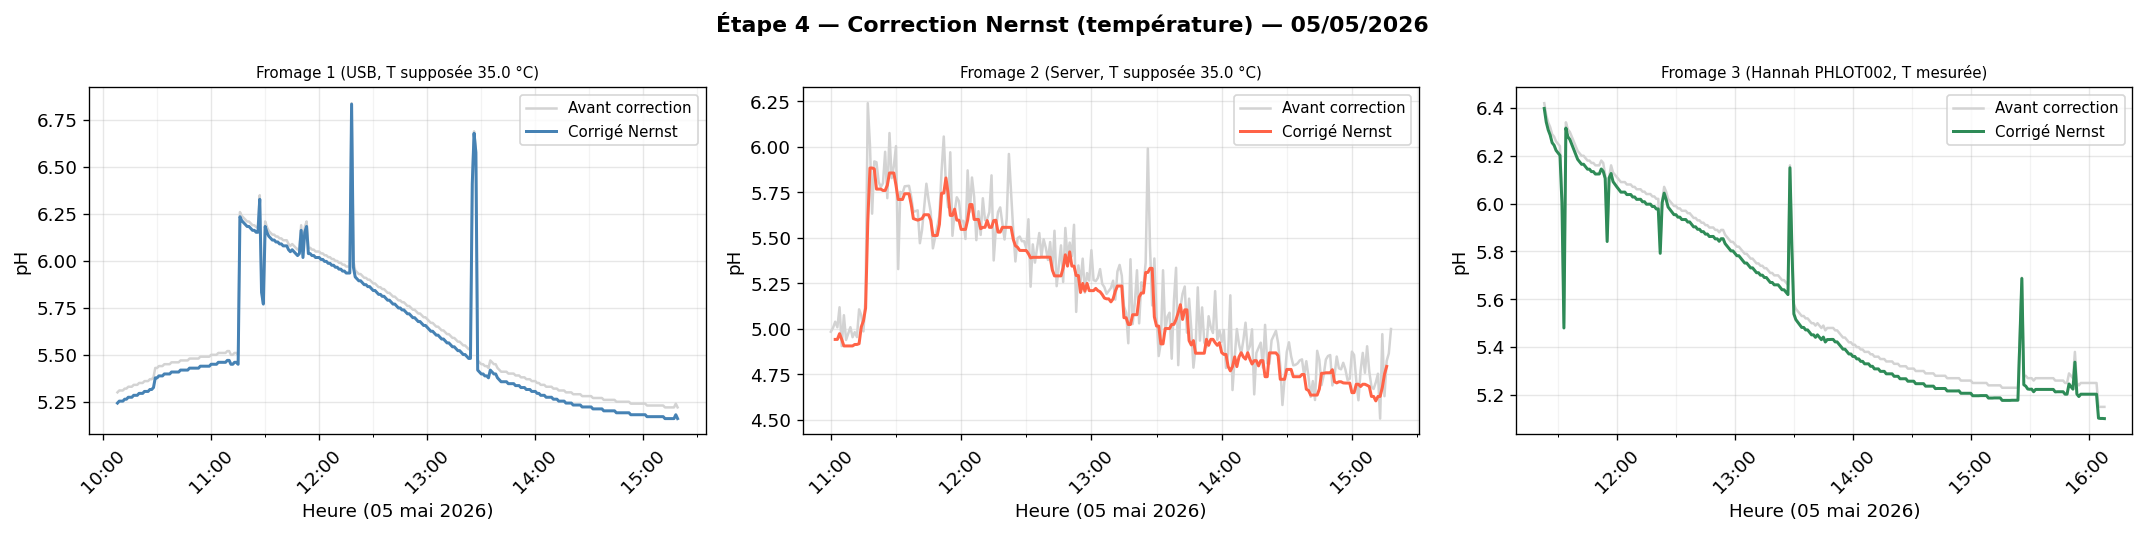

In [14]:
# ── Avant / après correction pour chaque fromage ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

pH2_corr_smooth = pH2_corr.rolling(window=5, center=True).median()

spec = [
    (df1_smooth, pH1_corr,        f'Fromage 1 (USB, T supposée {T_F1_ASSUMED} °C)', 'steelblue'),
    (df2_smooth, pH2_corr_smooth, f'Fromage 2 (Server, T supposée {T_F2_ASSUMED} °C)', 'tomato'),
    (pH3_meas,   pH3_corr,         'Fromage 3 (Hannah PHLOT002, T mesurée)', 'seagreen'),
]

for ax, (measured, corrected, label, color) in zip(axes, spec):
    ax.plot(measured.index,  measured.values,  color='lightgrey', linewidth=1.5,
            label='Avant correction')
    ax.plot(corrected.index, corrected.values, color=color, linewidth=1.8,
            label='Corrigé Nernst')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (05 mai 2026)')
    ax.legend(fontsize=9)

plt.suptitle('Étape 4 — Correction Nernst (température) — 05/05/2026', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_nernst_correction.png', bbox_inches='tight')
plt.show()

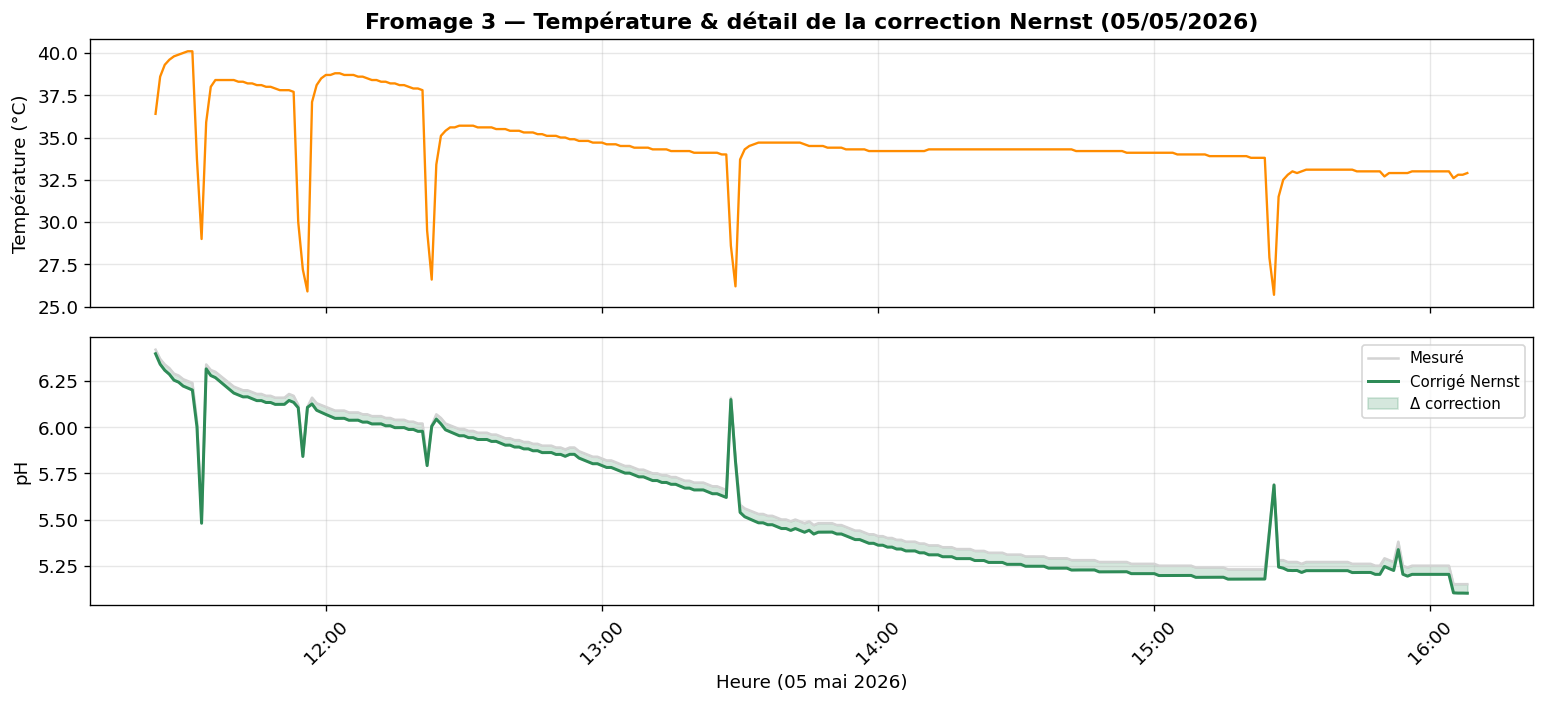

In [15]:
# ── Fromage 3 : détail correction vs. fluctuations de température ─────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(temp3.index, temp3.values, color='darkorange', linewidth=1.4)
axes[0].set_ylabel('Température (°C)')
axes[0].set_title('Fromage 3 — Température & détail de la correction Nernst (05/05/2026)',
                  fontweight='bold')

axes[1].plot(pH3_meas.index, pH3_meas.values, color='lightgrey', linewidth=1.5,
             label='Mesuré')
axes[1].plot(pH3_corr.index, pH3_corr.values, color='seagreen', linewidth=1.8,
             label='Corrigé Nernst')
axes[1].fill_between(pH3_meas.index, pH3_meas.values, pH3_corr.values,
                     alpha=0.2, color='seagreen', label='Δ correction')
axes[1].set_ylabel('pH')
axes[1].set_xlabel('Heure (05 mai 2026)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04b_nernst_fromage3_detail.png', bbox_inches='tight')
plt.show()

---
## 5. Comparaison Finale — Profils Corrigés & Fit Logistique

> **Session 05/05** : trois capteurs réels disponibles. L'USB démarre à 10:08 (Fromage 1), le Server à 11:00 (Fromage 2), Hannah à 11:23 (Fromage 3). La fenêtre de fit commune est fixée à la période de chevauchement actif des trois signaux.

In [ ]:
def logistic_decline(t, L, pH0, k, t0):
    """pH(t) = L + (pH0 - L) / (1 + exp(k*(t - t0)))"""
    return L + (pH0 - L) / (1 + np.exp(k * (t - t0)))

def fit_logistic(series, fit_start, fit_end):
    t_abs = series.index
    t = (t_abs - t_abs[0]).total_seconds() / 3600
    y = series.values
    mask = (t_abs >= fit_start) & (t_abs <= fit_end)
    t_fit, y_fit = t[mask], y[mask]
    if len(t_fit) < 4:
        print('Pas assez de points pour le fit.')
        return None, None
    p0 = [y.min(), y.max(), 2.0, np.median(t_fit)]
    try:
        popt, _ = curve_fit(logistic_decline, t_fit, y_fit, p0=p0, maxfev=10000)
        y_pred_all  = logistic_decline(t, *popt)
        y_pred_fit  = logistic_decline(t_fit, *popt)
        ss_res = np.sum((y_fit - y_pred_fit) ** 2)
        ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        return y_pred_all, r2
    except Exception as e:
        print(f'Fit échoué : {e}')
        return None, None

# Lissage visuel Server (rolling median 5 min)
pH2_corr_vis = pH2_corr.rolling(window=5, center=True).median().dropna()

# ── Fenêtres de fit — période de chevauchement actif des trois capteurs ──────
# USB démarre à 10:08, Hannah à 11:23 → fenêtre commune à partir de 11:30
# Sonde USB sortie vers 15:20 → fin de fenêtre à 15:15
FW_START = pd.Timestamp('2026-05-05 11:30')
FW_END   = pd.Timestamp('2026-05-05 15:15')

# USB couvre aussi la période 10:08–11:30 : on lui applique sa propre fenêtre étendue
FW_START_F1 = pd.Timestamp('2026-05-05 10:30')
FW_END_F1   = pd.Timestamp('2026-05-05 15:15')

fit1, r2_1 = fit_logistic(pH1_corr,     FW_START_F1, FW_END_F1)
fit2, r2_2 = fit_logistic(pH2_corr_vis, FW_START,    FW_END)
fit3, r2_3 = fit_logistic(pH3_corr,     FW_START,    FW_END)

fig, ax = plt.subplots(figsize=(14, 5))

ax.axvspan(FW_START,    FW_END,    alpha=0.08, color='green', label='Fenêtre fit commune')
ax.axvspan(FW_START_F1, FW_START,  alpha=0.05, color='steelblue', label='Fenêtre étendue USB')

ax.plot(pH1_corr.index,     pH1_corr.values,     color='steelblue', linewidth=1.2, alpha=0.8,
        label='Fromage 1 — USB')
ax.plot(pH2_corr_vis.index, pH2_corr_vis.values,  color='tomato',    linewidth=1.2, alpha=0.8,
        label='Fromage 2 — Server')
ax.plot(pH3_corr.index,     pH3_corr.values,     color='seagreen',  linewidth=1.2, alpha=0.8,
        label='Fromage 3 — Hannah PHLOT002')

if fit1 is not None:
    ax.plot(pH1_corr.index, fit1, color='steelblue', linewidth=2.5,
            linestyle='--', label=f'USB fit (R²={r2_1:.3f})')
if fit2 is not None:
    ax.plot(pH2_corr_vis.index, fit2, color='tomato', linewidth=2.5,
            linestyle='--', label=f'Server fit (R²={r2_2:.3f})')
if fit3 is not None:
    ax.plot(pH3_corr.index, fit3, color='seagreen', linewidth=2.5,
            linestyle='--', label=f'Hannah fit (R²={r2_3:.3f})')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
ax.grid(True, which='minor', alpha=0.15)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Heure (05 mai 2026)')
ax.set_ylabel('pH (corrigé Nernst)')
ax.set_title('pH fermentation curve — logistic decline fit (05/05/2026)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_final_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Table des jalons clés ──────────────────────────────────────────────────────
def first_crossing(series, threshold):
    below = series[series <= threshold]
    return below.index[0] if not below.empty else None

thresholds = [5.8, 5.5, 5.3, 5.2]
rows = []
for thr in thresholds:
    t1 = first_crossing(pH1_corr, thr)
    t2 = first_crossing(pH2_corr, thr)
    t3 = first_crossing(pH3_corr, thr)
    rows.append({
        'Seuil pH': thr,
        'Fromage 1 (proxy)': t1.strftime('%H:%M') if t1 else '—',
        'Fromage 2 (Server)': t2.strftime('%H:%M') if t2 else '—',
        'Fromage 3 (Hannah)': t3.strftime('%H:%M') if t3 else '—',
    })

df_milestones = pd.DataFrame(rows).set_index('Seuil pH')
print('Jalons d\'acidification (heure de franchissement) — 05/05/2026')
df_milestones

---
## 6. Modèle de Luedeking-Piret

Le modèle de Luedeking-Piret décrit la vitesse de production d'acide :

$$\frac{dA}{dt} = \alpha \cdot \frac{dX}{dt} + \beta \cdot X$$

- **α** : coefficient lié à la croissance (production associée à la croissance)
- **β** : coefficient non lié à la croissance (production à croissance nulle)
- **X(t)** : proxy de la biomasse (ajustement logistique sur la chute de pH)
- **A(t)** : proxy de la concentration en acide = pH₀ − pH(t)

In [ ]:
def prepare_lp_data(ph_series, fit_start, fit_end):
    """Prépare t, A, dA/dt, X, dX/dt sur la fenêtre de fit."""
    ph = ph_series[(ph_series.index >= fit_start) & (ph_series.index <= fit_end)]
    t  = (ph.index - ph.index[0]).total_seconds() / 3600

    A    = ph.values[0] - ph.values
    dAdt = np.gradient(A, t)

    A_norm = A / A.max() if A.max() > 0 else A
    dpHdt  = np.gradient(ph.values, t)
    t0_est = t[np.argmin(dpHdt)]

    def logistic_growth(t, k, t0):
        return 1 / (1 + np.exp(-k * (t - t0)))

    try:
        popt, _ = curve_fit(logistic_growth, t, A_norm, p0=[2.0, t0_est], maxfev=5000)
        k_fit, t0_fit = popt
    except Exception:
        k_fit, t0_fit = 2.0, t0_est

    X    = logistic_growth(t, k_fit, t0_fit)
    dXdt = k_fit * X * (1 - X)
    return t, A, dAdt, X, dXdt

def fit_luedeking_piret(dAdt, X, dXdt):
    """Régression linéaire : dA/dt = α·dX/dt + β·X"""
    design   = np.column_stack([dXdt, X])
    alpha, beta = np.linalg.lstsq(design, dAdt, rcond=None)[0]
    dAdt_pred   = alpha * dXdt + beta * X
    ss_res = np.sum((dAdt - dAdt_pred) ** 2)
    ss_tot = np.sum((dAdt - dAdt.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return alpha, beta, r2, dAdt_pred

# Mêmes fenêtres que la section 5
series_lp = [
    ('Fromage 1 (USB)',    pH1_corr,     'steelblue', FW_START_F1, FW_END_F1),
    ('Fromage 2 (Server)', pH2_corr_vis, 'tomato',    FW_START,    FW_END),
    ('Fromage 3 (Hannah)', pH3_corr,     'seagreen',  FW_START,    FW_END),
]

results_lp = {}
for name, ph_series, color, fw_s, fw_e in series_lp:
    try:
        t, A, dAdt, X, dXdt    = prepare_lp_data(ph_series, fw_s, fw_e)
        alpha, beta, r2, dAdt_pred = fit_luedeking_piret(dAdt, X, dXdt)
        results_lp[name] = dict(t=t, A=A, dAdt=dAdt, X=X, dXdt=dXdt,
                                dAdt_pred=dAdt_pred, alpha=alpha, beta=beta,
                                r2=r2, color=color)
    except Exception as e:
        print(f'{name} : erreur — {e}')

rows_lp = []
for name, res in results_lp.items():
    ratio = round(res['alpha'] / res['beta'], 2) if abs(res['beta']) > 1e-6 else '∞'
    dom   = 'croissance' if res['alpha'] > res['beta'] else 'stationnaire'
    rows_lp.append({
        'Fromage':                    name,
        'α (growth-assoc.)':          round(res['alpha'], 4),
        'β (non-growth-assoc.)':      round(res['beta'],  4),
        'α/β':                        ratio,
        'Dominance':                  dom,
        'R²':                         round(res['r2'], 3),
    })
pd.DataFrame(rows_lp).set_index('Fromage')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results_lp.items()):
    color = res['color']

    ax.plot(res['t'], res['dAdt'],       color='lightgrey', linewidth=1.2,
            label='dA/dt mesuré')
    ax.plot(res['t'], res['dAdt_pred'],  color=color,       linewidth=2.2,
            linestyle='--', label=f'LP fit (R²={res["r2"]:.3f})')

    ax.text(0.04, 0.92,
            f'α = {res["alpha"]:.4f}\nβ = {res["beta"]:.4f}\nα/β = {res["alpha"]/res["beta"]:.2f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Temps dans la fenêtre (h)')
    ax.set_ylabel('Vitesse d\'acidification (ΔpH/h)')
    ax.legend(fontsize=9)

plt.suptitle(
    'Section 6 — Modèle Luedeking-Piret — 05/05/2026\n'
    'dA/dt = α · dX/dt + β · X',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_luedeking_piret.png', bbox_inches='tight')
plt.show()

---
## 7. Notes & Prochaines Étapes

- [ ] Confirmer la température de calibration réelle de l'USB (supposée 25 °C → 35 °C à vérifier)
- [ ] Confirmer si PHLOT002 a été arrêté avant la fin réelle de la fermentation (pH final 5,15)
- [ ] Ajouter les scores sensoriels / texturaux dès qu'ils seront disponibles
- [ ] Corréler les paramètres du fit logistique (L, k, t0) avec le rendement frais
- [ ] Comparer les paramètres Luedeking-Piret avec la session du 28/04

| Session | Rendement frais | Capteurs actifs | pH final USB |
|---------|-----------------|-----------------|---------------|
| 28/04   | 12,17 %         | USB + Server + PHLOT001 | ~4.0 (sonde sortie) |
| 05/05   | 11,80 %         | USB + Server + PHLOT002 | 5,22 (à 15:20) |